# Open satellite SSH and interpolate to transect line

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import dask.array as da
from pathlib import Path

### First plot trend in SSH mm/yr 1993-2025

In [7]:
# ── Paths 
data_path = Path("~/efs-mount-point/mzahn/data/satellite_data/ssh_cmems_yearly/").expanduser()
out_path  = Path("~/efs-mount-point/mzahn/data/satellite_data/satellite_ssh_trend_1993_2025_mm_per_year.nc").expanduser()

files = sorted(data_path.glob("ssh_cmems_l4_0pt125deg_50N_65N_60W_40W_*.nc"))
print(f"Found {len(files)} files")

# ── Load data ──────────────────────────────────────────────────────────────────
ds = xr.open_mfdataset(
    files,
    combine="by_coords",
    chunks={"latitude": 100, "longitude": 100},  # spatial chunks work better for polyfit
)

ssh = ds["sla"]  # (time, lat, lon), units: metres

# ── Remove global (spatial + temporal) mean → anomaly ─────────────────────────
# Step 1: time-mean at each grid point  →  remove static SSH pattern
ssh_time_mean = ssh.mean(dim="time")
ssh_anom = ssh - ssh_time_mean

# Step 2: domain-mean at each time step →  remove large-scale common signal
#         (skip this block if you want absolute regional trends)
global_mean_ts = ssh_anom.mean(dim=["latitude", "longitude"])
ssh_anom = ssh_anom - global_mean_ts

# ── Convert time to decimal years ─────────────────────────────────────────────
# Use day-of-year / days-in-that-year so leap years are handled correctly
days_in_year = np.where(ssh_anom.time.dt.is_leap_year, 366.0, 365.0)
time_decimal  = (
    ssh_anom.time.dt.year
    + (ssh_anom.time.dt.dayofyear - 1) / days_in_year
)

ssh_anom = ssh_anom.assign_coords(time=("time", time_decimal.values))

# ── Linear trend via least-squares polyfit ────────────────────────────────────
# skipna=True lets polyfit skip land/ice NaN points without crashing
pf    = ssh_anom.polyfit(dim="time", deg=1, skipna=True)
trend = pf["polyfit_coefficients"].sel(degree=1)  # slope in m yr⁻¹

# ── Unit conversion & metadata ────────────────────────────────────────────────
trend_mm = (trend * 1000).rename("ssh_trend")
trend_mm.attrs.update({
    "units"      : "mm yr-1",
    "long_name"  : "Linear SSH trend",
    "description": (
        "Altimetry SLA linear trend 1993–2025. "
        "Time-mean and domain-mean removed before fitting."
    ),
    "source"     : "CMEMS L4 gridded SSH, 0.125°",
})

# ── Save ───────────────────────────────────────────────────────────────────────
trend_mm.to_dataset().to_netcdf(
    out_path,
    encoding={"ssh_trend": {"dtype": "float32", "zlib": True, "complevel": 4}},
)
print(f"Saved → {out_path}")

Found 33 files
Saved → /home/jpluser/efs-mount-point/mzahn/data/satellite_data/satellite_ssh_trend_1993_2025_mm_per_year.nc


In [8]:
# Open netcdf
trend_mm_per_year = xr.open_dataset('~/efs-mount-point/mzahn/data/satellite_data/satellite_ssh_trend_1993_2025_mm_per_year.nc')

In [4]:
# Open bathymetry
# bathy = xr.open_dataset('/Users/mzahn/data/GEBCO/GEBCO_2023.nc')
# bathy_greenland = bathy.elevation.sel(lon=slice(-65,-35),lat=slice(50,70))

bathy = xr.open_dataset("~/efs-mount-point/mzahn/data/bathy/gebco_2021_sub_ice_n90.0_s30.0_w-120.0_e30.0.nc")
bathy_greenland = bathy.elevation.sel(lon=slice(-65, -35),lat=slice(50, 70)).isel(lon=slice(None, None, 10),lat=slice(None, None, 10))

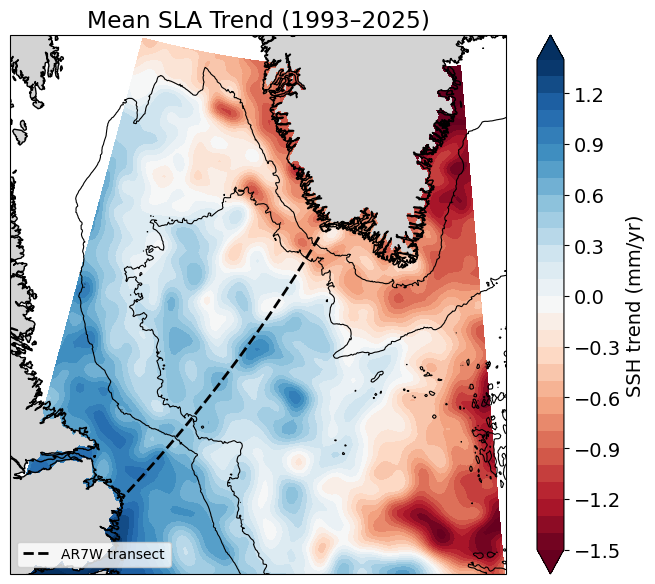

In [22]:
plt.rcParams['font.size'] = 14

# Plot map
lon = ds["longitude"]
lat = ds["latitude"]

fig = plt.figure(figsize=(8,7))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())  # Greenland region

# Contour-filled SSH trend
# levels = np.arange(-6, 6, 1)
levels = np.arange(-1.5, 1.5, 0.1)

cf = ax.contourf(
    lon,
    lat,
    trend_mm_per_year.ssh_trend,
    levels=levels,
    cmap="RdBu",
    extend="both",
    transform=ccrs.PlateCarree()
)

# Colorbar
cbar = plt.colorbar(cf, ax=ax, orientation="vertical", pad=0.05)
cbar.set_label("SSH trend (mm/yr)")

# Coastlines and land
ax.coastlines()
ax.add_feature(cfeature.LAND, color="lightgray")

# Bathymetry contours
bathy_levels = [-3000, -1000]

cs = ax.contour(
    bathy_greenland.lon,
    bathy_greenland.lat,
    bathy_greenland,
    levels=bathy_levels,
    colors="black",
    linewidths=0.8,
    linestyles="solid",
    transform=ccrs.PlateCarree()
)

# ax.clabel(cs, fmt=lambda x: f"{abs(int(x))} m", fontsize=8)

plt.title("Mean SLA Trend (1993–2025)")

ds_tr = xr.open_dataset(
    Path("~/efs-mount-point/mzahn/data/satellite_data/ssh_cmems_ar7w/ssh_cmems_ar7w_1993.nc").expanduser()
)

# AR7W transect line
ax.plot(
    ds_tr.longitude, ds_tr.latitude,
    color="k", linewidth=2.0,
    transform=ccrs.PlateCarree(), linestyle='dashed',
    zorder=5, label="AR7W transect"
)
ax.legend(loc="lower left", fontsize=10)

plt.show()

### Isolate transect from satellite SSH

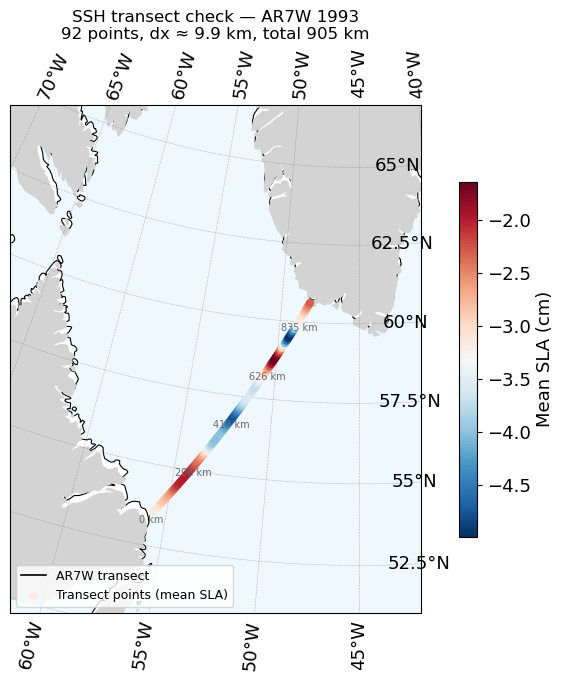

In [15]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

def plot_ssh_transect_check(year: int = 1993):
    """
    Open an interpolated AR7W SSH file and plot the transect points on a map
    to confirm the interpolation landed in the correct locations.
    
    Parameters
    ----------
    year : int
        Year to check (default 1993)
    """
    # ── Load file ─────────────────────────────────────────────────────────────
    fpath = Path(f"~/efs-mount-point/mzahn/data/satellite_data/ssh_cmems_ar7w/ssh_cmems_ar7w_{year}.nc").expanduser()
    ds = xr.open_dataset(fpath)

    tr_lat  = ds["latitude"].values        # (distance_km,)
    tr_lon  = ds["longitude"].values
    tr_dist = ds["distance_km"].values
    ssh_mean = ds["sla"].mean(dim="time").values   # time-mean SLA for coloring

    # ── Plot ──────────────────────────────────────────────────────────────────
    plt.rcParams["font.size"] = 13
    fig = plt.figure(figsize=(8, 7))
    ax  = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
    ax.set_extent([-62, -42, 51, 66], crs=ccrs.PlateCarree())

    # Transect line
    ax.plot(
        tr_lon, tr_lat,
        color="k", linewidth=1.2, transform=ccrs.PlateCarree(),
        zorder=3, label="AR7W transect"
    )

    # Scatter colored by time-mean SLA
    sc = ax.scatter(
        tr_lon, tr_lat,
        c=ssh_mean * 100,           # convert m → cm for display
        cmap="RdBu_r",
        s=25, marker="o",
        transform=ccrs.PlateCarree(),
        zorder=4, label="Transect points (mean SLA)"
    )
    plt.colorbar(sc, ax=ax, orientation="vertical",
                 label="Mean SLA (cm)", shrink=0.7, pad=0.05)

    # Mark SW and NE endpoints
    # for lon, lat, label in [
    #     (tr_lon[0],  tr_lat[0],  "SW (Labrador)"),
    #     (tr_lon[-1], tr_lat[-1], "NE (Greenland)"),
    # ]:
    #     ax.plot(lon, lat, "k^", ms=8, transform=ccrs.PlateCarree(), zorder=5)
    #     ax.text(lon + 0.3, lat, label, transform=ccrs.PlateCarree(),
    #             fontsize=9, zorder=6)

    # Annotate a few distance labels along the transect
    label_every_km = 200
    prev_labeled   = -label_every_km
    for i, d in enumerate(tr_dist):
        if d - prev_labeled >= label_every_km:
            ax.text(
                tr_lon[i], tr_lat[i] - 0.35,
                f"{int(d)} km",
                transform=ccrs.PlateCarree(),
                fontsize=7, ha="center", color="dimgray", zorder=6,
            )
            prev_labeled = d

    # Geography
    ax.coastlines(resolution="50m", linewidth=0.8)
    ax.add_feature(cfeature.LAND,  facecolor="lightgray", zorder=2)
    ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=1)
    ax.gridlines(draw_labels=True, linewidth=0.4, color="gray",
                 alpha=0.6, linestyle="--")

    plt.title(
        f"SSH transect check — AR7W {year}\n"
        f"{len(tr_dist)} points, dx ≈ {np.diff(tr_dist).mean():.1f} km, "
        f"total {tr_dist[-1]:.0f} km",
        fontsize=12,
    )
    ax.legend(loc="lower left", fontsize=9)
    plt.tight_layout()
    plt.show()
    ds.close()

# ── Run ───────────────────────────────────────────────────────────────────────
plot_ssh_transect_check(year=1993)

Found 33 files, loading ...


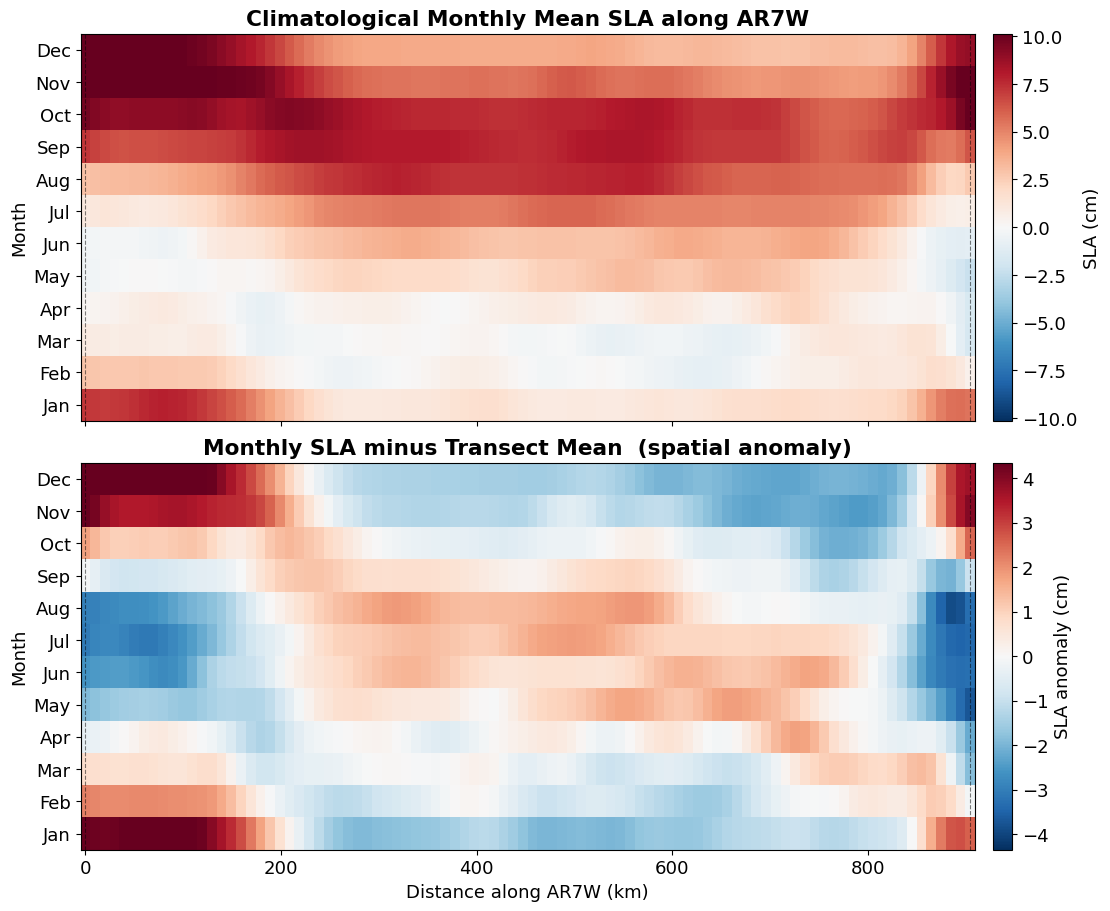

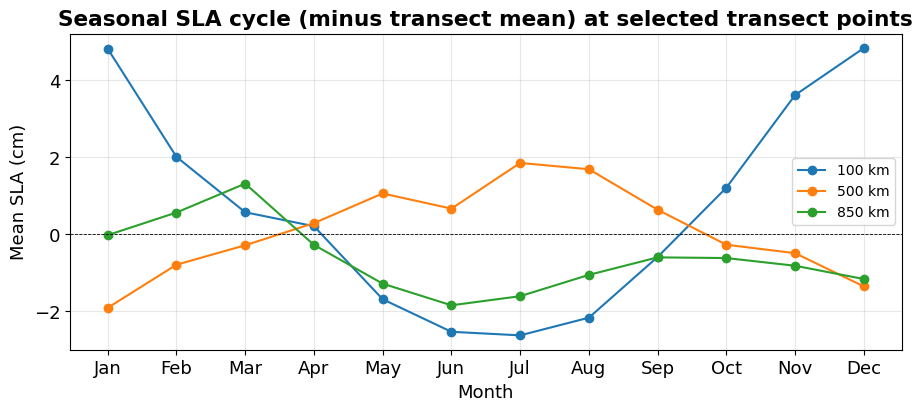

In [29]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

def plot_ssh_ar7w_seasonality():
    """
    Open all interpolated AR7W SSH files, compute the climatological
    monthly mean along the transect, and plot as a distance vs month heatmap.
    """
    # ── Load all files ────────────────────────────────────────────────────────
    data_path = Path("~/efs-mount-point/mzahn/data/satellite_data/ssh_cmems_ar7w/").expanduser()
    files = sorted(data_path.glob("ssh_cmems_ar7w_*.nc"))
    print(f"Found {len(files)} files, loading ...")

    ds = xr.open_mfdataset(files, combine="by_coords")
    sla = ds["sla"]   # (time, distance_km)

    # ── Compute climatological monthly mean ───────────────────────────────────
    sla_monthly_clim = (
        sla
        .groupby("time.month")
        .mean(dim="time")       # → (month, distance_km)
    )

    # Remove the distance-mean at each month so we see along-transect anomaly
    # (removes the basin-wide seasonal signal, isolates spatial structure)
    sla_anom = sla_monthly_clim - sla_monthly_clim.mean(dim="distance_km")

    dist   = ds["distance_km"].values
    months = np.arange(1, 13)
    month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]

    # ── Figure: 2 panels — absolute climatology and along-transect anomaly ────
    plt.rcParams["font.size"] = 13
    fig, axes = plt.subplots(
        2, 1, figsize=(11, 9),
        sharex=True, sharey=True,
        constrained_layout=True,
    )

    # --- Panel 1: Absolute monthly climatology ---
    clim_vals = sla_monthly_clim.values * 100   # m → cm
    vmax_abs  = np.nanpercentile(np.abs(clim_vals), 98)
    im0 = axes[0].pcolormesh(
        dist, months, clim_vals,
        cmap="RdBu_r",
        vmin=-vmax_abs, vmax=vmax_abs,
        shading="auto",
    )
    cb0 = plt.colorbar(im0, ax=axes[0], pad=0.02, label="SLA (cm)")
    axes[0].set_title("Climatological Monthly Mean SLA along AR7W", fontweight="bold")
    axes[0].set_ylabel("Month")
    axes[0].set_yticks(months)
    axes[0].set_yticklabels(month_labels)

    # --- Panel 2: Along-transect anomaly (distance-mean removed) ---
    anom_vals = sla_anom.values * 100
    vmax_anom = np.nanpercentile(np.abs(anom_vals), 98)
    im1 = axes[1].pcolormesh(
        dist, months, anom_vals,
        cmap="RdBu_r",
        vmin=-vmax_anom, vmax=vmax_anom,
        shading="auto",
    )
    cb1 = plt.colorbar(im1, ax=axes[1], pad=0.02, label="SLA anomaly (cm)")
    axes[1].set_title("Monthly SLA minus Transect Mean  (spatial anomaly)", fontweight="bold")
    axes[1].set_xlabel("Distance along AR7W (km)")
    axes[1].set_ylabel("Month")
    axes[1].set_yticks(months)
    axes[1].set_yticklabels(month_labels)

    # Mark SW / NE ends on both panels
    for ax in axes:
        ax.axvline(dist[0],  color="k", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.axvline(dist[-1], color="k", linewidth=0.8, linestyle="--", alpha=0.5)
        # ax.text(dist[0]  + 10, 11.6, "SW\n(Labrador)",  fontsize=8, va="top")
        # ax.text(dist[-1] - 10, 11.6, "NE\n(Greenland)", fontsize=8, va="top", ha="right")

    # ── Bonus: line plot of the seasonal cycle at a few key distances ─────────
    key_dists_km = [100, 500, 850]    # adjust to meaningful locations on your transect
    fig2, ax2 = plt.subplots(figsize=(9, 4), constrained_layout=True)
    colors = ["tab:blue", "tab:orange", "tab:green"]


    for kd, col in zip(key_dists_km, colors):
        idx  = np.argmin(np.abs(dist - kd))
        vals = sla_anom.isel(distance_km=idx).values * 100
        ax2.plot(months, vals, marker="o", color=col, label=f"{kd} km")

    ax2.axhline(0, color="k", linewidth=0.6, linestyle="--")
    ax2.set_xticks(months)
    ax2.set_xticklabels(month_labels)
    ax2.set_xlabel("Month")
    ax2.set_ylabel("Mean SLA (cm)")
    ax2.set_title("Seasonal SLA cycle (minus transect mean) at selected transect points", fontweight="bold")
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.show()
    ds.close()

# ── Run ───────────────────────────────────────────────────────────────────────
plot_ssh_ar7w_seasonality()